# 01: EDA & Preprocessing
**Project:** Robust Financial Fraud Detection using GNNs and Multimodal Fusion
**Author:** Israt Islam | 23082056 | University of Hertfordshire
**Dataset:** IEEE-CIS Fraud Detection (Vesta Corporation via Kaggle)
**Purpose:** Load raw data, perform exploratory data analysis, engineer features,
apply temporal split, and save processed outputs for downstream notebooks.

---

## 1. Environment Setup
Mount Google Drive, create folder structure, import libraries, and define helper functions.

In [1]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Base path — change only this if your folder is named differently ──────────
BASE = '/content/drive/MyDrive/FraudProject'

# ── Create folder structure (safe to run multiple times) ──────────────────────
import os
for folder in ['data', 'processed', 'models', 'figures']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

# ── Standard imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc       # garbage collection for memory management
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

def savefig(name):
    """
    Save the current matplotlib figure to the figures folder at 300dpi.
    300dpi is required for thesis-quality images.

    Args:
        name (str): Filename without extension (e.g. '01_class_distribution')
    """
    plt.savefig(f'{BASE}/figures/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> figures/{name}.png')

print('Environment ready.')
print('Base path:', BASE)

Mounted at /content/drive
Environment ready.
Base path: /content/drive/MyDrive/FraudProject


## 2. Memory Optimisation
The IEEE-CIS dataset is ~1.2GB. We downcast numerical columns to reduce RAM. We use **float32** (not float16) to avoid precision errors in ML operations.

In [2]:
def reduce_mem_usage(df, verbose=True):
    """
    Reduce memory usage of a DataFrame by downcasting numeric columns.
    Uses float32 (not float16) to prevent precision errors in sklearn/XGBoost/PyTorch.

    Args:
        df (pd.DataFrame): Input dataframe to optimise
        verbose (bool): Print memory reduction statistics

    Returns:
        pd.DataFrame: Memory-optimised dataframe
    """
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # Skip string/object columns
        if col_type == object:
            continue

        c_min, c_max = df[col].min(), df[col].max()

        # Downcast integer columns
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            # Use float32 (safe for all ML frameworks)
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'  Memory: {start_mem:.1f} MB -> {end_mem:.1f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df

print('Memory optimisation function defined.')

Memory optimisation function defined.


## 3. Load and Merge Data
We load both IEEE-CIS files and perform a **left join** on `TransactionID`. This creates our multimodal dataset combining transaction behaviour with digital identity fingerprints.

> **Note:** Place `train_transaction.csv` and `train_identity.csv` inside `FraudProject/data/` before running.

In [3]:
# ── Load transaction data (590k rows, ~400 features) ─────────────────────────
print('Loading Transaction data...')
train_trans = reduce_mem_usage(
    pd.read_csv(f'{BASE}/data/train_transaction.csv')
)
print(f'  Transaction shape: {train_trans.shape}')

# ── Load identity data (digital fingerprints: device, browser, network) ───────
print('Loading Identity data...')
train_id = reduce_mem_usage(
    pd.read_csv(f'{BASE}/data/train_identity.csv')
)
print(f'  Identity shape: {train_id.shape}')

# ── Left join: keep all transactions, attach identity where available ──────────
# Left join preserves all 590k transactions even if no identity data exists
print('Merging datasets (left join on TransactionID)...')
df = pd.merge(train_trans, train_id, on='TransactionID', how='left')

# ── Free memory ───────────────────────────────────────────────────────────────
del train_trans, train_id
gc.collect()

# ── Summary statistics ────────────────────────────────────────────────────────
print(f'Merged shape:  {df.shape}')
print(f'Fraud cases:   {df["isFraud"].sum():,} ({df["isFraud"].mean()*100:.2f}%)')
print(f'Legit cases:   {(df["isFraud"]==0).sum():,}')

Loading Transaction data...
  Memory: 1775.2 MB -> 916.3 MB (48.4% reduction)
  Transaction shape: (590540, 394)
Loading Identity data...
  Memory: 45.1 MB -> 31.9 MB (29.3% reduction)
  Identity shape: (144233, 41)
Merging datasets (left join on TransactionID)...
Merged shape:  (590540, 434)
Fraud cases:   20,663 (3.50%)
Legit cases:   569,877


## 4. Data Audit
Before analysis we audit data types, missing value rates, and basic statistics. This directly informs all preprocessing decisions.

In [4]:
# ── Basic dataset statistics ──────────────────────────────────────────────────
print('='*55)
print('DATA AUDIT')
print('='*55)
print(f'Shape:       {df.shape}')
print(f'Memory:      {df.memory_usage().sum()/1024**2:.1f} MB')
print(f'Duplicates:  {df.duplicated().sum()}')
print()

# ── Missing value analysis ────────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

# Create summary of columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
print(f'Columns with >80% missing:   {(missing_pct > 80).sum()}')
print(f'Columns with >50% missing:   {(missing_pct > 50).sum()}')
print()
print('Top 15 columns by missingness:')
print(missing_df.head(15).to_string())

DATA AUDIT
Shape:       (590540, 434)
Memory:      1044.7 MB
Duplicates:  0

Columns with missing values: 414 / 434
Columns with >80% missing:   74
Columns with >50% missing:   214

Top 15 columns by missingness:
       Missing Count  Missing %
id_24         585793       99.2
id_26         585377       99.1
id_25         585408       99.1
id_23         585371       99.1
id_27         585371       99.1
id_08         585385       99.1
id_21         585381       99.1
id_22         585371       99.1
id_07         585385       99.1
dist2         552913       93.6
D7            551623       93.4
id_18         545427       92.4
D14           528353       89.5
D13           528588       89.5
D12           525823       89.0


## 5. EDA: Class Distribution
With only 3.5% fraud cases the dataset is severely imbalanced. Accuracy is therefore misleading — we use AUC-ROC, F1, Precision, Recall, and FPR throughout.

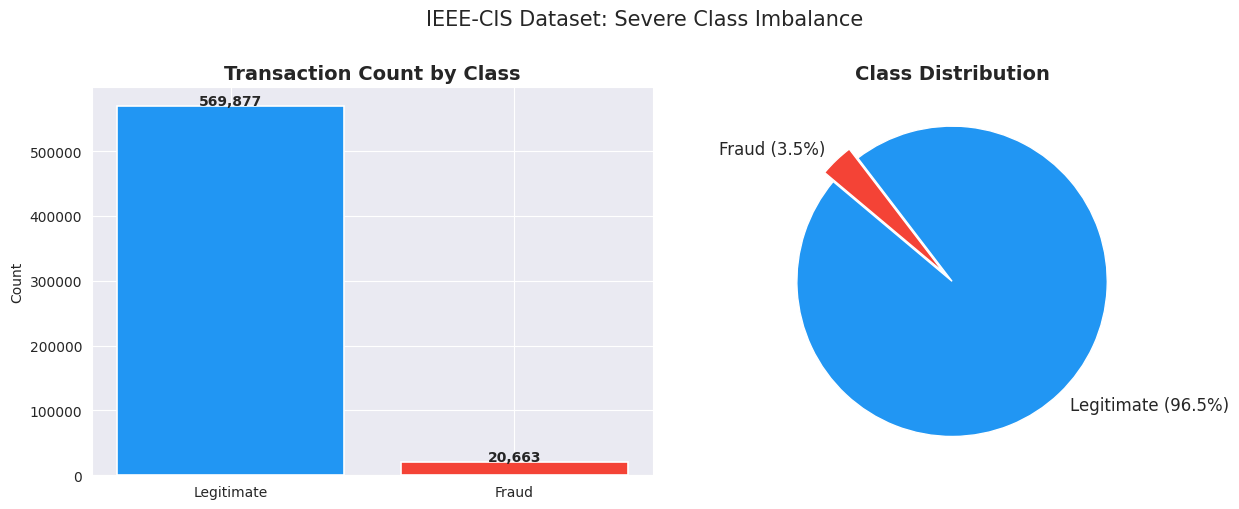

  Saved -> figures/01_class_distribution.png


In [5]:
# ── Plot class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of raw counts
counts = df['isFraud'].value_counts()
bars = axes[0].bar(
    ['Legitimate', 'Fraud'],
    counts.values,
    color=['#2196F3', '#F44336'],
    edgecolor='white',
    linewidth=1.2
)
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Add count labels on bars
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{val:,}', ha='center', fontweight='bold'
    )

# Pie chart of percentages
fraud_rate = df['isFraud'].mean() * 100
axes[1].pie(
    [100-fraud_rate, fraud_rate],
    labels=[f'Legitimate ({100-fraud_rate:.1f}%)', f'Fraud ({fraud_rate:.1f}%)'],
    colors=['#2196F3', '#F44336'],
    explode=[0, 0.08],
    startangle=140,
    textprops={'fontsize': 12}
)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.suptitle('IEEE-CIS Dataset: Severe Class Imbalance', fontsize=15, y=1.01)
plt.tight_layout()
savefig('01_class_distribution')

## 6. EDA: Transaction Amount Analysis
Fraudulent transactions may cluster at specific amount ranges. We use log scale to handle the wide range of values.

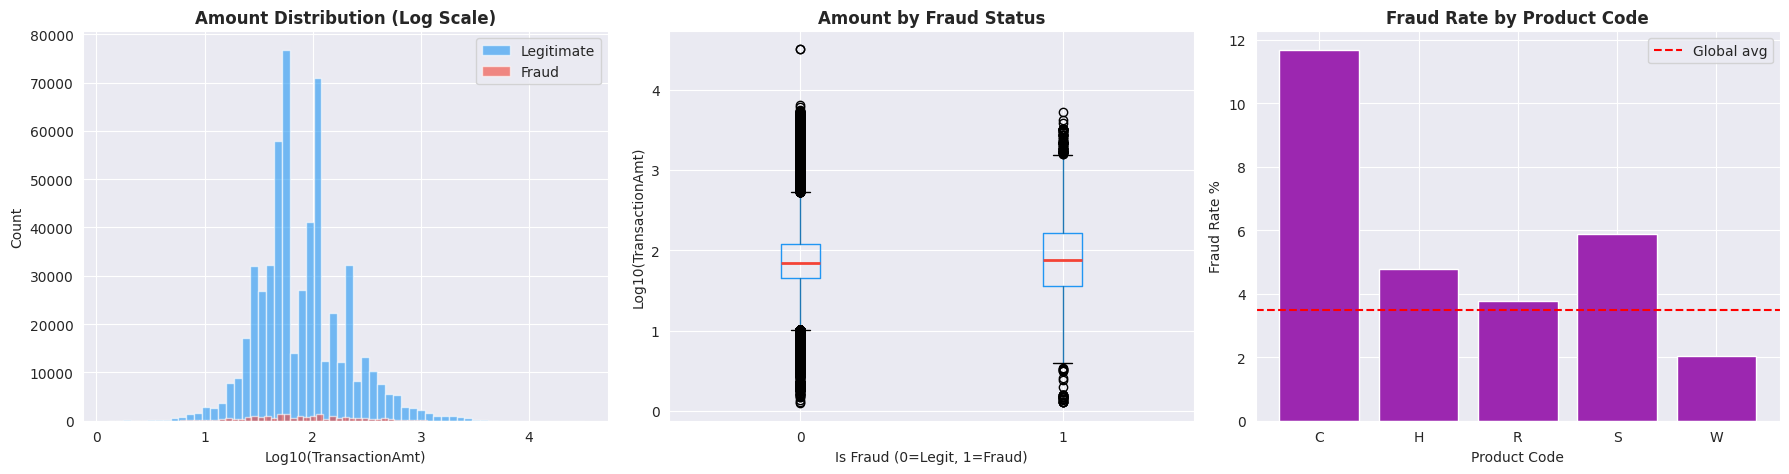

  Saved -> figures/02_transaction_amount.png


In [6]:
# ── Create log-transformed amount feature ─────────────────────────────────────
# Log transformation normalises the right-skewed distribution
df['log_amt'] = np.log10(df['TransactionAmt'] + 1).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram: log amount distribution by fraud status
for label, grp in df.groupby('isFraud')['TransactionAmt']:
    axes[0].hist(
        np.log10(grp + 1), bins=60, alpha=0.6,
        label='Fraud' if label==1 else 'Legitimate',
        color='#F44336' if label==1 else '#2196F3'
    )
axes[0].set_xlabel('Log10(TransactionAmt)')
axes[0].set_ylabel('Count')
axes[0].set_title('Amount Distribution (Log Scale)', fontweight='bold')
axes[0].legend()

# Box plot: amount by fraud status
df.boxplot(
    column='log_amt', by='isFraud', ax=axes[1],
    boxprops=dict(color='#2196F3'),
    medianprops=dict(color='#F44336', linewidth=2)
)
axes[1].set_title('Amount by Fraud Status', fontweight='bold')
axes[1].set_xlabel('Is Fraud (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Log10(TransactionAmt)')
plt.suptitle('')

# Bar chart: fraud rate by product code
product_fraud = df.groupby('ProductCD')['isFraud'].mean() * 100
axes[2].bar(product_fraud.index, product_fraud.values, color='#9C27B0', edgecolor='white')
axes[2].axhline(df['isFraud'].mean()*100, color='red', linestyle='--', label='Global avg')
axes[2].set_title('Fraud Rate by Product Code', fontweight='bold')
axes[2].set_xlabel('Product Code')
axes[2].set_ylabel('Fraud Rate %')
axes[2].legend()

plt.tight_layout()
savefig('02_transaction_amount')

## 7. EDA: Temporal Patterns
`TransactionDT` is seconds from a reference point. We extract hour and day features to identify when fraud peaks.

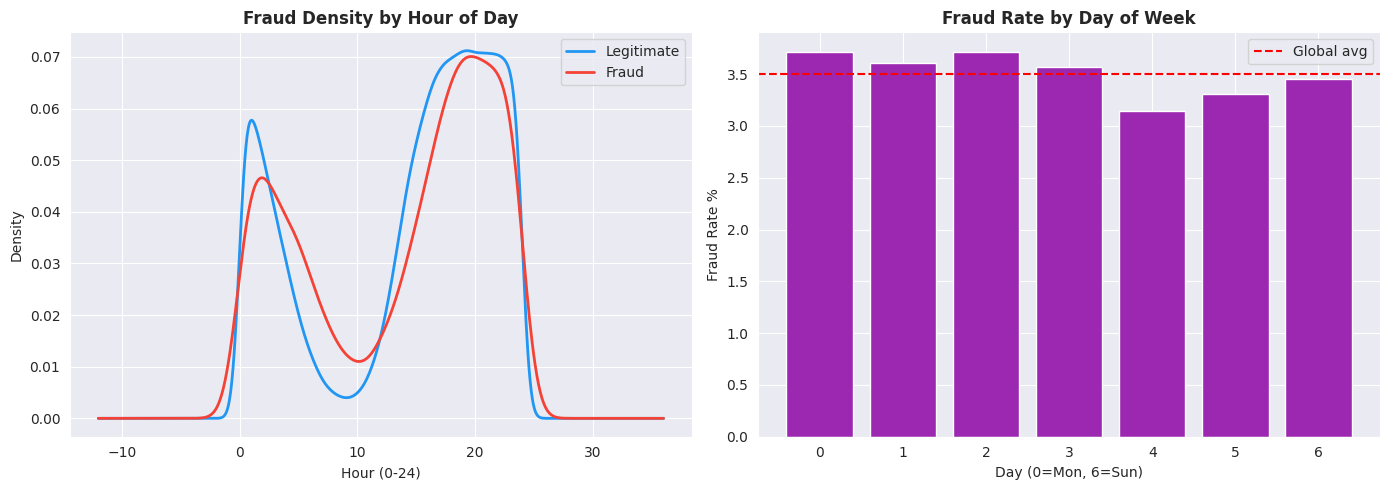

  Saved -> figures/03_temporal_patterns.png


In [7]:
# ── Extract temporal features from TransactionDT ──────────────────────────────
# TransactionDT is a time delta in seconds from a reference date
df['hour']        = (df['TransactionDT'] / 3600) % 24      # hour of day (0-23)
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7     # day of week (0=Mon)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot: fraud density by hour of day
for label, grp in df.groupby('isFraud')['hour']:
    grp.plot.kde(
        ax=axes[0],
        label='Fraud' if label==1 else 'Legitimate',
        color='#F44336' if label==1 else '#2196F3',
        linewidth=2
    )
axes[0].set_title('Fraud Density by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0-24)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Bar chart: fraud rate by day of week
day_fraud = df.groupby('day_of_week')['isFraud'].mean() * 100
axes[1].bar(day_fraud.index, day_fraud.values, color='#9C27B0', edgecolor='white')
axes[1].axhline(df['isFraud'].mean()*100, color='red', linestyle='--', label='Global avg')
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day (0=Mon, 6=Sun)')
axes[1].set_ylabel('Fraud Rate %')
axes[1].legend()

plt.tight_layout()
savefig('03_temporal_patterns')

## 8. EDA: Device, Email Domain and Regional Analysis
Three identity-modal features: device type, purchaser email, and billing region — all part of the digital fingerprint.

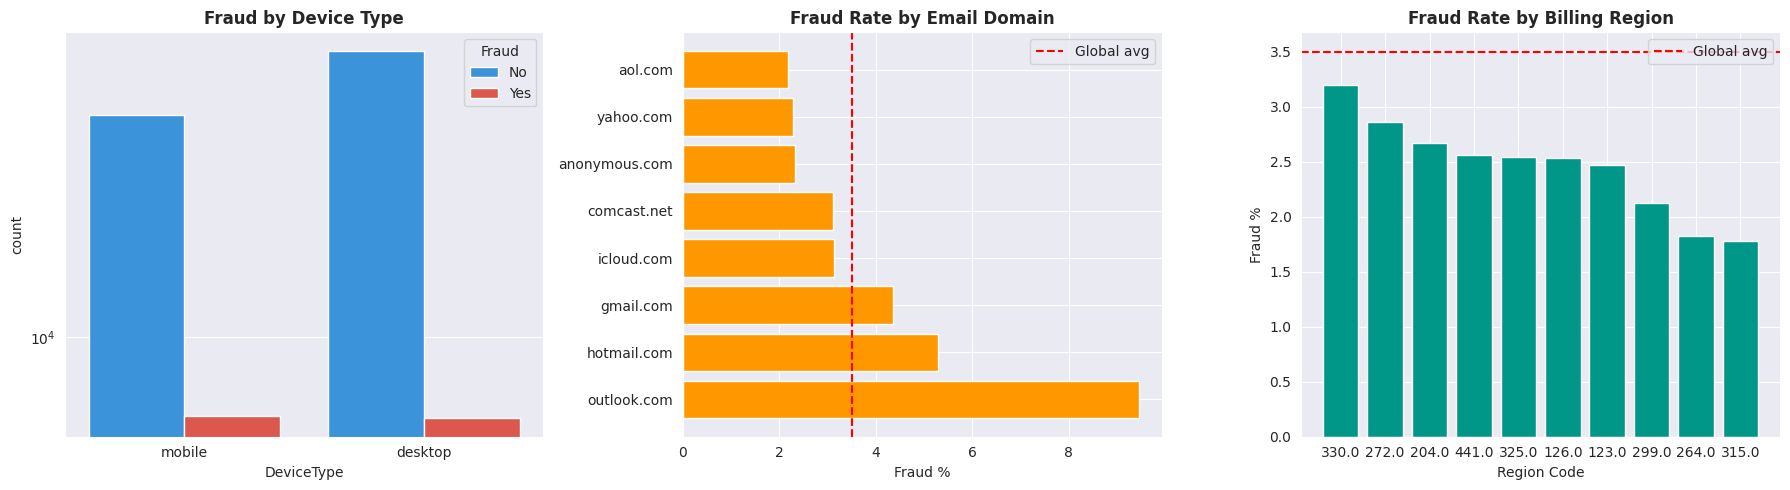

  Saved -> figures/04_device_email_region.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Device type fraud analysis ────────────────────────────────────────────────
# Drop rows where DeviceType is null for this plot only
device_data = df.dropna(subset=['DeviceType'])
sns.countplot(
    data=device_data, x='DeviceType', hue='isFraud',
    palette={0:'#2196F3', 1:'#F44336'}, ax=axes[0]
)
axes[0].set_yscale('log')  # log scale because legitimate transactions vastly outnumber fraud
axes[0].set_title('Fraud by Device Type', fontweight='bold')
axes[0].legend(title='Fraud', labels=['No', 'Yes'])

# ── Email domain fraud rate ───────────────────────────────────────────────────
# Focus on top 8 most common email domains
top_emails  = df['P_emaildomain'].value_counts().nlargest(8).index
email_fraud = (
    df[df['P_emaildomain'].isin(top_emails)]
    .groupby('P_emaildomain')['isFraud']
    .mean()
    .sort_values(ascending=False) * 100
)
axes[1].barh(email_fraud.index, email_fraud.values, color='#FF9800')
axes[1].axvline(df['isFraud'].mean()*100, color='red', linestyle='--', label='Global avg')
axes[1].set_title('Fraud Rate by Email Domain', fontweight='bold')
axes[1].set_xlabel('Fraud %')
axes[1].legend()

# ── Regional fraud rate ───────────────────────────────────────────────────────
# Focus on top 10 billing regions by transaction volume
top_regions  = df['addr1'].value_counts().nlargest(10).index
region_fraud = (
    df[df['addr1'].isin(top_regions)]
    .groupby('addr1')['isFraud']
    .mean()
    .sort_values(ascending=False) * 100
)
axes[2].bar(region_fraud.index.astype(str), region_fraud.values, color='#009688')
axes[2].axhline(df['isFraud'].mean()*100, color='red', linestyle='--', label='Global avg')
axes[2].set_title('Fraud Rate by Billing Region', fontweight='bold')
axes[2].set_xlabel('Region Code')
axes[2].set_ylabel('Fraud %')
axes[2].legend()

plt.tight_layout()
savefig('04_device_email_region')

## 9. EDA: Missing Value Heatmap
Visualising missingness reveals that the identity block has up to 40% nulls. Our `null_count` feature captures this signal explicitly.

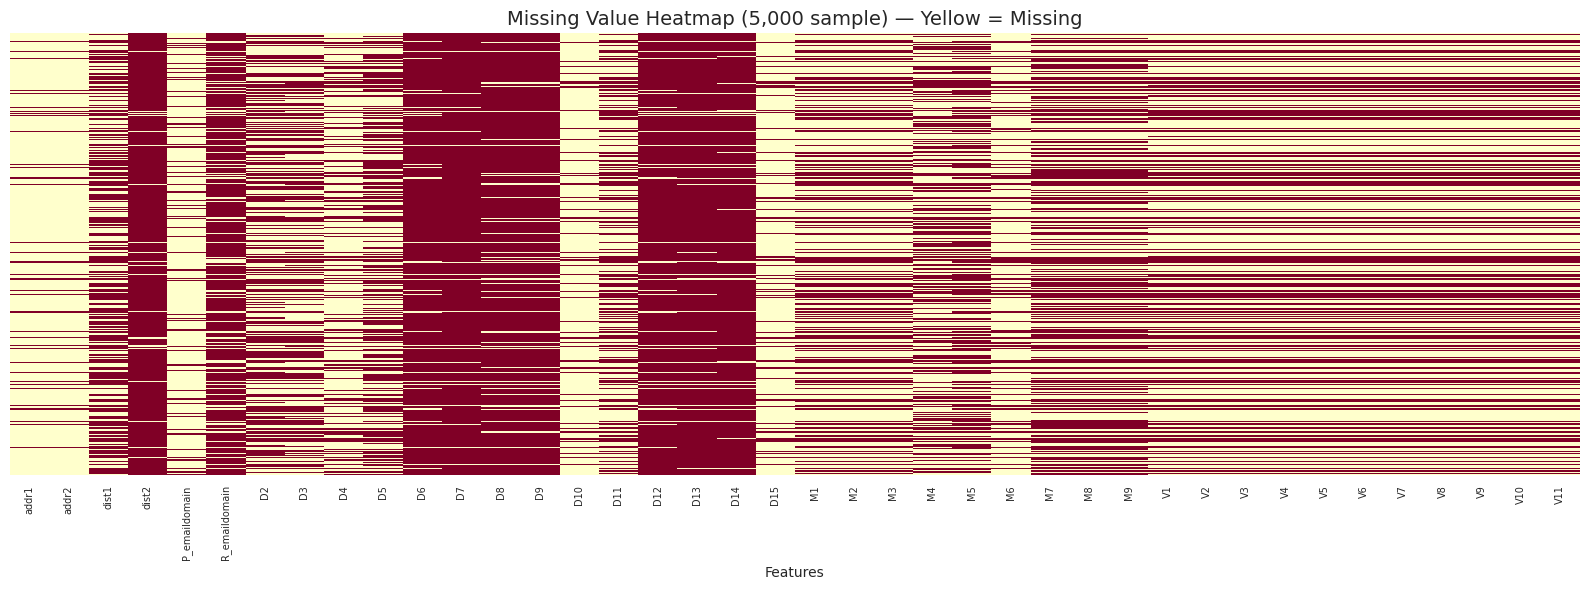

  Saved -> figures/05_missing_heatmap.png


In [9]:
# ── Sample 5000 rows for speed (heatmap is slow on full dataset) ──────────────
sample    = df.sample(5000, random_state=42)

# Select columns with >5% missing for meaningful visualisation
miss_cols = df.columns[df.isnull().mean() > 0.05].tolist()[:40]

plt.figure(figsize=(16, 6))
sns.heatmap(
    sample[miss_cols].isnull(),
    cbar=False,
    cmap='YlOrRd',
    yticklabels=False  # hide row labels (too many)
)
plt.title('Missing Value Heatmap (5,000 sample) — Yellow = Missing', fontsize=14)
plt.xlabel('Features')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
savefig('05_missing_heatmap')

## 10. EDA: Card Type and Null Count Analysis
Fraud rates by card network and category, plus the null count distribution showing synthetic identities have more missing fields.

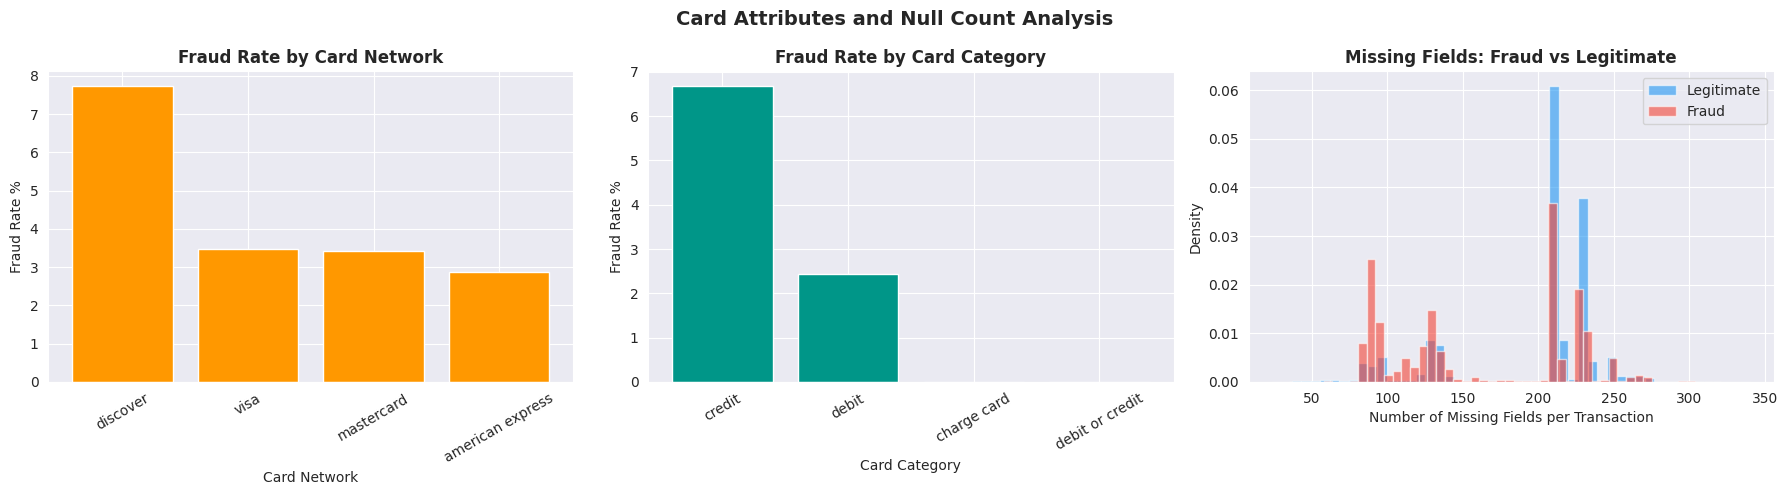

  Saved -> figures/06_card_and_nulls.png


In [10]:
# ── Create null_count feature BEFORE plotting ────────────────────────────────
# null_count = number of missing fields per transaction row
# Synthetic identity fraud often leaves many fields blank
df['null_count'] = df.isnull().sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Card network fraud rate (Visa, Mastercard etc.) ───────────────────────────
card4_fraud = df.groupby('card4')['isFraud'].mean().dropna() * 100
card4_fraud = card4_fraud.sort_values(ascending=False)
axes[0].bar(card4_fraud.index, card4_fraud.values, color='#FF9800', edgecolor='white')
axes[0].set_title('Fraud Rate by Card Network', fontweight='bold')
axes[0].set_xlabel('Card Network')
axes[0].set_ylabel('Fraud Rate %')
axes[0].tick_params(axis='x', rotation=30)

# ── Card category fraud rate (debit, credit etc.) ─────────────────────────────
card6_fraud = df.groupby('card6')['isFraud'].mean().dropna() * 100
card6_fraud = card6_fraud.sort_values(ascending=False)
axes[1].bar(card6_fraud.index, card6_fraud.values, color='#009688', edgecolor='white')
axes[1].set_title('Fraud Rate by Card Category', fontweight='bold')
axes[1].set_xlabel('Card Category')
axes[1].set_ylabel('Fraud Rate %')
axes[1].tick_params(axis='x', rotation=30)

# ── Null count distribution: fraud vs legitimate ───────────────────────────────
# Key insight: fraud transactions tend to have MORE missing fields
df[df['isFraud']==0]['null_count'].hist(
    bins=50, alpha=0.6, color='#2196F3', label='Legitimate', density=True, ax=axes[2]
)
df[df['isFraud']==1]['null_count'].hist(
    bins=50, alpha=0.6, color='#F44336', label='Fraud', density=True, ax=axes[2]
)
axes[2].set_title('Missing Fields: Fraud vs Legitimate', fontweight='bold')
axes[2].set_xlabel('Number of Missing Fields per Transaction')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Card Attributes and Null Count Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('06_card_and_nulls')

## 11. Feature Engineering
We create 7 domain-informed features based on fraud detection literature. These encode behavioural signals invisible in raw features.

| Feature | Rationale |
|---|---|
| `null_count` | Synthetic identities have more missing fields |
| `hour` | Fraud peaks at off-hours |
| `day_of_week` | Weekly fraud patterns |
| `email_mismatch` | Purchaser != recipient email is a fraud signal |
| `card1_txn_count` | High velocity on one card = suspicious |
| `amt_zscore` | Unusual amount for that card = suspicious |
| `log_amt` | Normalises skewed amounts |

In [11]:
print('Engineering features...')

# ── Feature 1: Email domain mismatch ──────────────────────────────────────────
# If purchaser email != recipient email, flag as mismatch (binary feature)
df['email_mismatch'] = (
    df['P_emaildomain'].fillna('unknown') !=
    df['R_emaildomain'].fillna('unknown')
).astype(np.int8)

# ── Feature 2: Transaction velocity per card ──────────────────────────────────
# How many total transactions has this card made? High count = velocity fraud risk
df['card1_txn_count'] = df.groupby('card1')['card1'].transform('count')

# ── Feature 3: Amount z-score per card ────────────────────────────────────────
# How unusual is this transaction amount compared to this card's history?
# High z-score = unusually large amount for this card
card1_mean    = df.groupby('card1')['TransactionAmt'].transform('mean')
card1_std     = df.groupby('card1')['TransactionAmt'].transform('std').fillna(1)
df['amt_zscore'] = ((df['TransactionAmt'] - card1_mean) / card1_std).astype(np.float32)

# ── Confirm all features exist ────────────────────────────────────────────────
engineered = ['null_count', 'hour', 'day_of_week', 'email_mismatch',
              'card1_txn_count', 'amt_zscore', 'log_amt']
for feat in engineered:
    status = 'OK' if feat in df.columns else 'MISSING'
    print(f'  {feat:20} {status}')

print(f'\nTotal features: {df.shape[1]}')

Engineering features...
  null_count           OK
  hour                 OK
  day_of_week          OK
  email_mismatch       OK
  card1_txn_count      OK
  amt_zscore           OK
  log_amt              OK

Total features: 441


## 12. Preprocessing Pipeline
Four-step pipeline: drop high-null columns, impute remaining nulls, encode categoricals, fill sentinel values.

In [12]:
print('Running preprocessing pipeline...')

# ── Step 1: Drop columns with >80% missing values ────────────────────────────
# These columns have too little data to be useful
missing_rate = df.isnull().mean()
drop_cols    = missing_rate[missing_rate > 0.80].index.tolist()
df.drop(columns=drop_cols, inplace=True)
print(f'  Step 1: Dropped {len(drop_cols)} columns with >80% missing')

# ── Step 2: Separate target variable ─────────────────────────────────────────
y          = df['isFraud'].values
feature_df = df.drop(columns=['isFraud', 'TransactionID'])

# ── Step 3: Impute numeric nulls with median ──────────────────────────────────
# Median is robust to outliers (better than mean for skewed distributions)
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    feature_df[col].fillna(feature_df[col].median(), inplace=True)
print(f'  Step 2: Imputed {len(numeric_cols)} numeric columns with median')

# ── Step 4: Encode categorical columns ───────────────────────────────────────
# LabelEncoder converts string categories to integers
cat_cols = feature_df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    feature_df[col].fillna('missing', inplace=True)  # fill nulls first
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
print(f'  Step 3: Encoded {len(cat_cols)} categorical columns')

# ── Step 5: Final null fill with sentinel value ───────────────────────────────
# -999 is used as XGBoost handles this natively as a missing value indicator
feature_df.fillna(-999, inplace=True)
print(f'  Step 4: Filled remaining NaNs with -999')

print(f'\nFinal feature matrix: {feature_df.shape}')
print(f'Remaining NaNs:       {feature_df.isnull().sum().sum()}')

Running preprocessing pipeline...
  Step 1: Dropped 74 columns with >80% missing
  Step 2: Imputed 339 numeric columns with median
  Step 3: Encoded 26 categorical columns
  Step 4: Filled remaining NaNs with -999

Final feature matrix: (590540, 365)
Remaining NaNs:       0


## 13. Temporal Train/Test Split
**Critical decision:** Sort by `TransactionDT`, use first 80% for training and last 20% for testing. This prevents data leakage — in production, models always train on past data and predict future transactions.

In [13]:
# ── Sort all data by transaction time ─────────────────────────────────────────
# This ensures training data is always BEFORE test data in time
# Random splits would allow future transactions into training (data leakage)
time_order = df['TransactionDT'].argsort().values
feature_df = feature_df.iloc[time_order].reset_index(drop=True)
y_sorted   = y[time_order]

# ── 80/20 temporal split ──────────────────────────────────────────────────────
split_idx = int(len(feature_df) * 0.80)

X_train = feature_df.iloc[:split_idx]   # first 80% of time
X_test  = feature_df.iloc[split_idx:]   # last 20% of time
y_train = y_sorted[:split_idx]
y_test  = y_sorted[split_idx:]

print('Temporal Split Complete')
print(f'  Train: {len(X_train):,} rows | Fraud: {y_train.mean()*100:.2f}%')
print(f'  Test:  {len(X_test):,} rows  | Fraud: {y_test.mean()*100:.2f}%')
print('  No random split. No data leakage.')

Temporal Split Complete
  Train: 472,432 rows | Fraud: 3.51%
  Test:  118,108 rows  | Fraud: 3.44%
  No random split. No data leakage.


## 14. Save All Outputs
Save in **Parquet format** — 10x faster than CSV. Downstream notebooks load instantly without reprocessing.

In [14]:
print('Saving processed outputs to Drive...')

# ── Save train/test feature matrices ──────────────────────────────────────────
X_train.to_parquet(f'{BASE}/processed/X_train.parquet')
X_test.to_parquet(f'{BASE}/processed/X_test.parquet')
print(f'  X_train.parquet saved: {X_train.shape}')
print(f'  X_test.parquet  saved: {X_test.shape}')

# ── Save labels as numpy arrays ───────────────────────────────────────────────
np.save(f'{BASE}/processed/y_train.npy', y_train)
np.save(f'{BASE}/processed/y_test.npy',  y_test)
print(f'  y_train.npy saved: {y_train.shape}')
print(f'  y_test.npy  saved: {y_test.shape}')

# ── Save full processed dataframe (needed for graph construction in NB03) ─────
df.to_parquet(f'{BASE}/processed/train_processed.parquet')
print(f'  train_processed.parquet saved: {df.shape}')

# ── Save feature names for reference ──────────────────────────────────────────
with open(f'{BASE}/processed/feature_names.json', 'w') as f:
    json.dump(list(X_train.columns), f)
print(f'  feature_names.json saved: {len(X_train.columns)} features')

print()
print('NOTEBOOK 01 COMPLETE')
print('Next -> 02_Baseline_Models.ipynb')

Saving processed outputs to Drive...
  X_train.parquet saved: (472432, 365)
  X_test.parquet  saved: (118108, 365)
  y_train.npy saved: (472432,)
  y_test.npy  saved: (118108,)
  train_processed.parquet saved: (590540, 367)
  feature_names.json saved: 365 features

NOTEBOOK 01 COMPLETE
Next -> 02_Baseline_Models.ipynb


---
## Notebook Summary

| Step | Description | Output |
|---|---|---|
| Load | Merged transaction + identity (590k rows) | train_processed.parquet |
| EDA | Class distribution, amounts, temporal, device, email, cards | 6 PNG figures |
| Features | 7 engineered features | Added to matrix |
| Preprocessing | Drop >80% null, impute, encode | Clean matrix |
| Split | Temporal 80/20 | X_train, X_test, y_* |

**Next:** `02_Baseline_Models.ipynb`